# Day 20 of ML 30-Days Challenge

# Task

**Decision Tree & Random Forest Classification**: Apply these ensemble methods to classification. Learn about splitting criteria like Gini impurity and information gain, which decision trees use to find the most informative features to split on.

- **Gini impurity**: “How mixed up are the labels?”
If a node has 50% class A and 50% class B, it’s very mixed (high impurity). If it’s all one class, it’s pure (low impurity). A split is good if it makes the child nodes less mixed.
- **Information gain (entropy)**: “How much chaos did we remove?”
Entropy measures disorder. A split is good if it turns a chaotic node into more orderly child nodes. The more disorder it removes, the higher the information gain.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## For GINI Impurity

###0. Create the Base

In [54]:
CRITERION = 'gini'       # change to 'entropy' to use information gain
N_TREES   = 200          # number of trees in RandomForest
TEST_SIZE = 0.30
RANDOM_SEED = 42

###1. Create a 200 rows Dataset

In [55]:
X, y = make_classification(
    n_samples=200, n_features=4, n_informative=3, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.2, random_state=RANDOM_SEED
)
cols = ['feat1','feat2','feat3','feat4']
df = pd.DataFrame(X, columns=cols)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split( df[cols], df['target'], test_size=TEST_SIZE, stratify=df['target'], random_state= RANDOM_SEED)

###2. Defining both Decision Tree and Random Forest Classifier models

In [56]:
tree = DecisionTreeClassifier(criterion=CRITERION, random_state=RANDOM_SEED).fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

rf = RandomForestClassifier( n_estimators=N_TREES, criterion=CRITERION, random_state=RANDOM_SEED ).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

f"Accuracy : Decision Tree: {(acc_tree*100):.2f}% | Random Forest: {(acc_rf*100):.2f}%"

'Accuracy : Decision Tree: 86.67% | Random Forest: 90.00%'

###3. Feature importance (RF)

In [57]:
feat_imp = pd.DataFrame({
    'feature': cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"Criterion: {CRITERION}")
print(f"Decision Tree accuracy: {acc_tree:.4f}")
print(f"Random Forest accuracy: {acc_rf:.4f}")
print("Random Forest feature importances:\n\n", feat_imp)

Criterion: gini
Decision Tree accuracy: 0.8667
Random Forest accuracy: 0.9000
Random Forest feature importances:

   feature  importance
1   feat2    0.738297
0   feat1    0.099441
3   feat4    0.095106
2   feat3    0.067156


###4. Visualization (gini)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


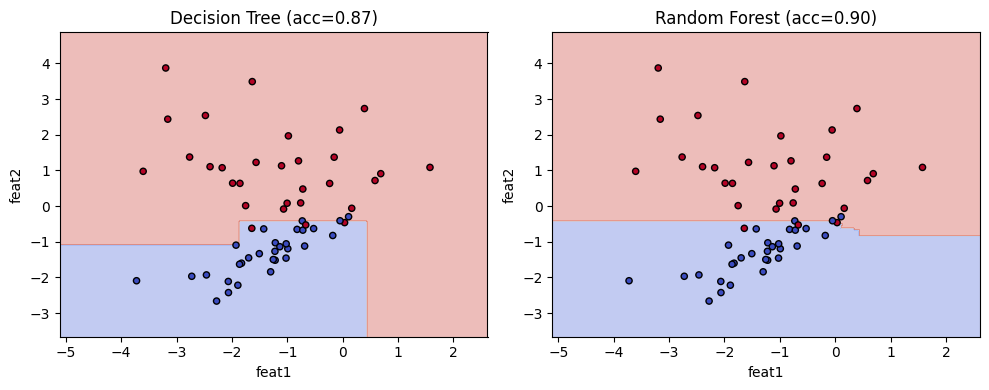

In [58]:
f3, f4 = X_train['feat3'].mean(), X_train['feat4'].mean()
x_min, x_max = df['feat1'].min()-1.0, df['feat1'].max()+1.0
y_min, y_max = df['feat2'].min()-1.0, df['feat2'].max()+1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350),
                     np.linspace(y_min, y_max, 350))
grid = np.c_[xx.ravel(), yy.ravel(),
             np.full(xx.size, f3),
             np.full(xx.size, f4)]

Z_tree = tree.predict(grid).reshape(xx.shape)
Z_rf = rf.predict(grid).reshape(xx.shape)

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.contourf(xx, yy, Z_tree, cmap='coolwarm', alpha=0.35)
ax1.scatter(X_test['feat1'], X_test['feat2'], c=y_test, cmap='coolwarm', edgecolor='k', s=20)
ax1.set_title(f'Decision Tree (acc={acc_tree:.2f})')
ax1.set_xlabel('feat1'); ax1.set_ylabel('feat2')

ax2.contourf(xx, yy, Z_rf, cmap='coolwarm', alpha=0.35)
ax2.scatter(X_test['feat1'], X_test['feat2'], c=y_test, cmap='coolwarm', edgecolor='k', s=20)
ax2.set_title(f'Random Forest (acc={acc_rf:.2f})')
ax2.set_xlabel('feat1'); ax2.set_ylabel('feat2')

plt.tight_layout()
plt.show()

## For Information Gain (Entropy)

###0. Create the Base

In [64]:
CRITERION = 'entropy'
N_TREES   = 200
TEST_SIZE = 0.30
RANDOM_SEED = 45

###1. Create a 200 rows Dataset

In [65]:
X, y = make_classification(
    n_samples=200, n_features=4, n_informative=3, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.2, random_state=RANDOM_SEED
)
cols = ['feat1','feat2','feat3','feat4']
df = pd.DataFrame(X, columns=cols)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split( df[cols], df['target'], test_size=TEST_SIZE, stratify=df['target'], random_state= RANDOM_SEED)

###2. Defining both Decision Tree and Random Forest Classifier models

In [66]:
tree = DecisionTreeClassifier(criterion=CRITERION, random_state=RANDOM_SEED).fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

rf = RandomForestClassifier( n_estimators=N_TREES, criterion=CRITERION, random_state=RANDOM_SEED ).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

f"Accuracy : Decision Tree: {(acc_tree*100):.2f}% | Random Forest: {(acc_rf*100):.2f}%"

'Accuracy : Decision Tree: 98.33% | Random Forest: 98.33%'

###3. Feature importance (RF)

In [67]:
feat_imp = pd.DataFrame({
    'feature': cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"Criterion: {CRITERION}")
print(f"Decision Tree accuracy: {acc_tree:.4f}")
print(f"Random Forest accuracy: {acc_rf:.4f}")
print("Random Forest feature importances:\n\n", feat_imp)

Criterion: entropy
Decision Tree accuracy: 0.9833
Random Forest accuracy: 0.9833
Random Forest feature importances:

   feature  importance
0   feat1    0.549635
1   feat2    0.263499
3   feat4    0.181440
2   feat3    0.005426


###4. Visualization (Entropy)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


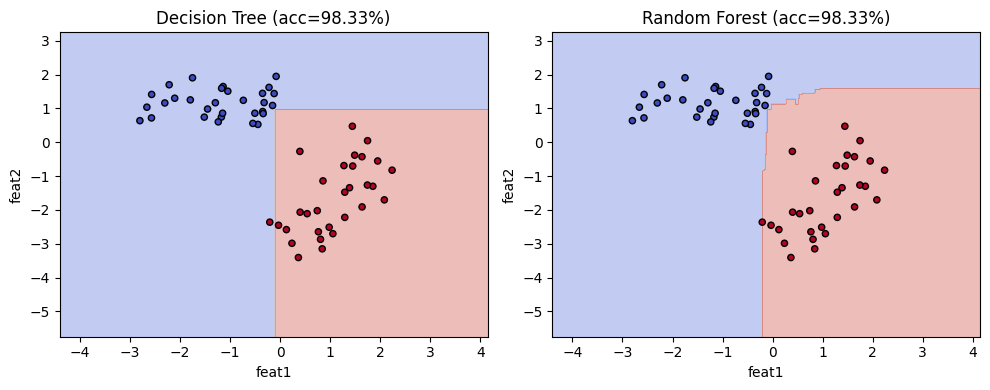

In [68]:
f3, f4 = X_train['feat3'].mean(), X_train['feat4'].mean()
x_min, x_max = df['feat1'].min()-1.0, df['feat1'].max()+1.0
y_min, y_max = df['feat2'].min()-1.0, df['feat2'].max()+1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 350),
                     np.linspace(y_min, y_max, 350))
grid = np.c_[xx.ravel(), yy.ravel(),
             np.full(xx.size, f3),
             np.full(xx.size, f4)]

Z_tree = tree.predict(grid).reshape(xx.shape)
Z_rf = rf.predict(grid).reshape(xx.shape)

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.contourf(xx, yy, Z_tree, cmap='coolwarm', alpha=0.35)
ax1.scatter(X_test['feat1'], X_test['feat2'], c=y_test, cmap='coolwarm', edgecolor='k', s=20)
ax1.set_title(f'Decision Tree (acc={acc_tree*100:.2f}%)')
ax1.set_xlabel('feat1'); ax1.set_ylabel('feat2')

ax2.contourf(xx, yy, Z_rf, cmap='coolwarm', alpha=0.35)
ax2.scatter(X_test['feat1'], X_test['feat2'], c=y_test, cmap='coolwarm', edgecolor='k', s=20)
ax2.set_title(f'Random Forest (acc={acc_rf*100:.2f}%)')
ax2.set_xlabel('feat1'); ax2.set_ylabel('feat2')

plt.tight_layout()
plt.show()